# Part 2.A — Intent Classification and Slot Filling

Two things have to be predicted for every ATIS utterance: what the user wants (the
**intent**), and which words fill which semantic role (the **slots**, tagged in BIO
format). I train one decoder-only Transformer from scratch and put two output heads on
it, so a single model does both jobs.

```
utterance : i want to fly from boston at 838 am
slots     : O O O O O B-fromloc.city_name O B-depart_time.time I-depart_time.time
intent    : flight
```

Slots are scored with F1 through `conll.evaluate` and intents with plain accuracy. To
pick a model I combine them into one number,

$$J = \tfrac{1}{2}F1_{slot} + \tfrac{1}{2}Acc_{intent}$$

otherwise it's not obvious what to do when one metric goes up and the other goes down.

Like Part 1.A I change one thing at a time:

| Step | What changes |
|------|--------------|
| 0 | Learning rate, architecture held fixed |
| 1 | `d_model`, then `n_heads`, then `num_layers`, then `ff_dim` |
| 2 | Dropout before the output heads |

Every configuration runs with **three seeds** and I report mean ± std, because on a
dataset this small a single run moves around quite a bit and I didn't want to read noise
as a result. Model choice is made on the dev set; test is only used at the very end.

The intent prediction comes from a `cls` token stuck on the end of each utterance. It has
to go at the end rather than the start — attention here is causal, so only the last
position has actually seen the whole sentence.

## 1. Setup

In [1]:
import os
import json
import math
import copy
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

from conll import evaluate

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
SEEDS        = [42, 43, 44]     # three seeds per config
SEED         = SEEDS[0]
PAD_TOKEN    = 0
N_EPOCHS     = 40
PATIENCE     = 6
WEIGHT_DECAY = 0.01
CLIP         = 5.0
BATCH_SIZE   = 128

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda:0
GPU   : Tesla T4


## 2. Data

ATIS doesn't come with a dev split, so I take 10% out of train. The split is stratified
on intent so the rare ones don't all end up on one side. A few intents show up exactly
once and can't be stratified at all, so those just stay in train.

In [2]:
def load_json(path):
    with open(path) as f:
        return json.load(f)


tmp_train = load_json('dataset/ATIS/train.json')
test_raw  = load_json('dataset/ATIS/test.json')

counts = Counter(x['intent'] for x in tmp_train)
single  = [x for x in tmp_train if counts[x['intent']] == 1]
multi   = [x for x in tmp_train if counts[x['intent']] > 1]

train_raw, dev_raw = train_test_split(
    multi, test_size=0.10, random_state=SEED, shuffle=True,
    stratify=[x['intent'] for x in multi])
train_raw += single

print(f'Train: {len(train_raw)} | Dev: {len(dev_raw)} | Test: {len(test_raw)}')
print(f'Intents in corpus: {len(counts)} | singleton intents kept in train: {len(single)}')
print('\nExample:')
print(json.dumps(train_raw[0], indent=1))

Train: 4480 | Dev: 498 | Test: 893
Intents in corpus: 22 | singleton intents kept in train: 4

Example:
{
 "utterance": "what is the cost for these flights from baltimore to philadelphia",
 "slots": "O O O O O O O O B-fromloc.city_name O B-toloc.city_name",
 "intent": "airfare"
}


### Vocabularies

Built from train only — if dev or test words leaked in here the evaluation wouldn't mean
anything. Anything unseen later becomes `unk`.

In [3]:
class Lang:
    def __init__(self, corpus, cutoff=0):
        self.word2id   = self._w2id([x['utterance'] for x in corpus], cutoff)
        self.slot2id   = self._lab2id(sum([x['slots'].split() for x in corpus], []))
        self.intent2id = self._lab2id([x['intent'] for x in corpus], pad=False)
        self.id2word   = {v: k for k, v in self.word2id.items()}
        self.id2slot   = {v: k for k, v in self.slot2id.items()}
        self.id2intent = {v: k for k, v in self.intent2id.items()}

    def _w2id(self, utterances, cutoff=0):
        # cls goes on the end of every utterance and its hidden state is what the
        # intent head reads
        vocab = {'pad': PAD_TOKEN, 'unk': 1, 'cls': 2}
        for word, freq in Counter(sum([u.split() for u in utterances], [])).items():
            if freq > cutoff and word not in vocab:
                vocab[word] = len(vocab)
        return vocab

    def _lab2id(self, elements, pad=True):
        # some intents only turn up in test (day_name for one), so they need
        # somewhere to go instead of blowing up with a KeyError
        vocab = {'pad': PAD_TOKEN, 'unk': 1} if pad else {'unk': 0}
        for e in sorted(set(elements)):
            if e not in vocab:
                vocab[e] = len(vocab)
        return vocab


lang = Lang(train_raw, cutoff=0)

table1 = pd.DataFrame([
    {'Split': 'Train', 'Utterances': len(train_raw), 'Purpose': 'Parameter learning'},
    {'Split': 'Dev',   'Utterances': len(dev_raw),   'Purpose': 'Model selection'},
    {'Split': 'Test',  'Utterances': len(test_raw),  'Purpose': 'Final held-out evaluation'},
])
display(table1)
print(f'Vocabulary: {len(lang.word2id)} words | Slots: {len(lang.slot2id)} | '
      f'Intents: {len(lang.intent2id)}')

,Split,Utterances,Purpose
0,Train,4480,Parameter learning
1,Dev,498,Model selection
2,Test,893,Final held-out evaluation


Vocabulary: 867 words | Slots: 121 | Intents: 23


### Dataset and batching

Words, slots and intents all become ids. Batches get padded to the longest utterance in
the batch, and I keep the real lengths around: the model needs them to find the `cls`
position, and scoring needs them to cut the padding back off.

In [4]:
class IntentsAndSlots(data.Dataset):
    def __init__(self, dataset, lang, unk='unk'):
        self.lang = lang
        self.unk_id = lang.word2id[unk]
        self.utt_ids, self.slot_ids, self.intent_ids = [], [], []
        self.words, self.gold_slots = [], []      # raw strings, kept for scoring
        for x in dataset:
            words = x['utterance'].split()
            slots = x['slots'].split()
            assert len(words) == len(slots), 'word/slot length mismatch'
            # cls at the end, not the start - attention is causal so the last
            # position is the only one that has seen everything
            self.utt_ids.append([lang.word2id.get(w, self.unk_id) for w in words]
                                + [lang.word2id['cls']])
            # unseen slots and the cls position both get PAD so they stay out of the loss
            self.slot_ids.append([lang.slot2id.get(s, PAD_TOKEN) for s in slots]
                                 + [PAD_TOKEN])
            self.intent_ids.append(lang.intent2id.get(x['intent'], lang.intent2id['unk']))
            self.words.append(words)
            self.gold_slots.append(slots)

    def __len__(self):
        return len(self.utt_ids)

    def __getitem__(self, idx):
        return {'utterance': torch.tensor(self.utt_ids[idx]),
                'slots':     torch.tensor(self.slot_ids[idx]),
                'intent':    self.intent_ids[idx],
                'words':     self.words[idx],
                'gold':      self.gold_slots[idx]}


def collate_fn(batch):
    def pad(seqs):
        lengths = [len(s) for s in seqs]
        out = torch.full((len(seqs), max(lengths)), PAD_TOKEN, dtype=torch.long)
        for i, s in enumerate(seqs):
            out[i, :len(s)] = s
        return out, torch.tensor(lengths)

    batch.sort(key=lambda x: len(x['utterance']), reverse=True)
    utts,  lengths = pad([b['utterance'] for b in batch])
    slots, _       = pad([b['slots'] for b in batch])
    return {'utterances': utts.to(DEVICE),
            'y_slots':    slots.to(DEVICE),
            'intents':    torch.tensor([b['intent'] for b in batch]).to(DEVICE),
            'lengths':    lengths.to(DEVICE),
            'words':      [b['words'] for b in batch],
            'gold':       [b['gold'] for b in batch]}


train_loader = DataLoader(IntentsAndSlots(train_raw, lang), batch_size=BATCH_SIZE,
                          collate_fn=collate_fn, shuffle=True)
dev_loader   = DataLoader(IntentsAndSlots(dev_raw, lang), batch_size=64,
                          collate_fn=collate_fn)
test_loader  = DataLoader(IntentsAndSlots(test_raw, lang), batch_size=64,
                          collate_fn=collate_fn)

print(f'Batches -- train: {len(train_loader)} | dev: {len(dev_loader)} | '
      f'test: {len(test_loader)}')

Batches -- train: 35 | dev: 8 | test: 14


## 3. Model

Same transformer as Part 1.A, with two heads bolted on:

- the **slot head** classifies every position
- the **intent head** reads only the `cls` position at the end

`dropout` is the Step 2 change and feeds both heads.

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'
        self.n_heads, self.h_dim = n_heads, d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout  = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        B, L, d = x.size()
        q = self.w_q(x).view(B, L, self.n_heads, self.h_dim).transpose(1, 2)
        k = self.w_k(x).view(B, L, self.n_heads, self.h_dim).transpose(1, 2)
        v = self.w_v(x).view(B, L, self.n_heads, self.h_dim).transpose(1, 2)
        sim  = (q @ k.transpose(-2, -1)) / math.sqrt(self.h_dim)
        sim  = sim.masked_fill(mask == 0, float('-inf'))
        attn = self.attn_dropout(F.softmax(sim, dim=-1))
        y = (attn @ v).transpose(1, 2).contiguous().view(B, L, d)
        return self.resid_dropout(self.out_proj(y))


class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_dim, dropout=0.0):
        super().__init__()
        self.linear1 = nn.Linear(d_model, hidden_dim)
        self.act     = nn.GELU()
        self.linear2 = nn.Linear(hidden_dim, d_model)
        self.ff_dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.ff_dropout(self.linear2(self.act(self.linear1(x))))


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, dropout=0.0):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, ff_dim, dropout)

    def forward(self, x, mask):
        x = x + self.attn(self.ln1(x), mask)
        x = x + self.ff(self.ln2(x))
        return x

In [6]:
MAX_LEN = 64


class JointGPT2(nn.Module):
    def __init__(self, vocab_size, n_slots, n_intents, max_len=MAX_LEN, d_model=128,
                 n_heads=2, num_layers=2, ff_dim=512, dropout=0.0):
        super().__init__()
        self.max_len = max_len
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_TOKEN)
        self.pos_embed   = nn.Embedding(max_len, d_model)
        self.emb_dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ff_dim, dropout) for _ in range(num_layers)])
        self.ln_f = nn.LayerNorm(d_model)

        # Step 2: dropout right before the two output layers
        self.out_dropout = nn.Dropout(dropout)
        self.slot_head   = nn.Linear(d_model, n_slots)
        self.intent_head = nn.Linear(d_model, n_intents)

        mask = torch.tril(torch.ones(max_len, max_len)).unsqueeze(0).unsqueeze(0)
        self.register_buffer('mask', mask)

    def forward(self, utterances, lengths):
        B, L = utterances.shape
        pos = torch.arange(L, device=utterances.device)
        x = self.emb_dropout(self.token_embed(utterances) + self.pos_embed(pos))
        for block in self.blocks:
            x = block(x, self.mask[:, :, :L, :L])
        x = self.ln_f(x)

        slot_logits = self.slot_head(self.out_dropout(x))          # (B, L, n_slots)

        # last real token of each utterance -- the only position that saw everything
        last = x[torch.arange(B, device=x.device), lengths - 1]
        intent_logits = self.intent_head(self.out_dropout(last))   # (B, n_intents)
        return slot_logits, intent_logits


def init_weights(mat):
    for m in mat.modules():
        if isinstance(m, nn.Linear):
            nn.init.uniform_(m.weight, -0.01, 0.01)
            if m.bias is not None:
                m.bias.data.fill_(0.01)


print('Model defined.')

Model defined.


## 4. Training and evaluation

The loss is just the two cross-entropies added together. Padding is ignored in the slot
loss, and since `cls` is padded there too it never affects slot training.

For scoring I trim each predicted sequence back to its real length, drop the `cls`
position, and turn it into `(word, label)` pairs, which is what `conll.evaluate` wants.
Gold labels come from the original strings rather than through the id mapping — a slot
that never appeared in training would otherwise be silently scored as padding.

In [7]:
def train_loop(loader, optimizer, criterion_slots, criterion_intents, model, clip=CLIP):
    model.train()
    losses = []
    for sample in loader:
        optimizer.zero_grad()
        slots, intent = model(sample['utterances'], sample['lengths'])
        loss = (criterion_intents(intent, sample['intents'])
                + criterion_slots(slots.permute(0, 2, 1), sample['y_slots']))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        losses.append(loss.item())
    return sum(losses) / len(losses)


def eval_loop(loader, criterion_slots, criterion_intents, model, lang):
    model.eval()
    losses = []
    ref_slots, hyp_slots = [], []
    ref_intents, hyp_intents = [], []

    with torch.no_grad():
        for sample in loader:
            slots, intent = model(sample['utterances'], sample['lengths'])
            loss = (criterion_intents(intent, sample['intents'])
                    + criterion_slots(slots.permute(0, 2, 1), sample['y_slots']))
            losses.append(loss.item())

            ref_intents.extend(sample['intents'].tolist())
            hyp_intents.extend(torch.argmax(intent, dim=1).tolist())

            pred = torch.argmax(slots, dim=2)
            for i, seq in enumerate(pred):
                n = sample['lengths'][i].item() - 1      # cut the cls back off
                # use the original label strings here, otherwise a slot missing from the
                # train vocab would quietly be scored as padding
                words = sample['words'][i]
                gold  = sample['gold'][i]
                got   = [lang.id2slot[s] for s in seq[:n].tolist()]
                ref_slots.append(list(zip(words, gold)))
                hyp_slots.append(list(zip(words, got)))

    try:
        slot_f1 = evaluate(ref_slots, hyp_slots)['total']['f']
    except Exception as e:      # a degenerate run can predict no spans at all
        print('  conll evaluate failed:', e)
        slot_f1 = 0.0

    acc = sum(int(a == b) for a, b in zip(ref_intents, hyp_intents)) / len(ref_intents)
    joint = 0.5 * slot_f1 + 0.5 * acc        # the joint score used for picking models
    return slot_f1, acc, joint, sum(losses) / len(losses)

### Experiment runner

`train_one` does a single seed and returns the scores of whichever epoch had the best dev
joint score. `run_experiment` calls it three times and averages, so every row in the
tables below is mean ± std over three seeds.

In [8]:
results = []


def train_one(seed, lr, d_model, n_heads, num_layers, ff_dim, dropout,
              n_epochs=N_EPOCHS, patience=PATIENCE):
    # run a single seed, return the scores of the best dev epoch
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    model = JointGPT2(len(lang.word2id), len(lang.slot2id), len(lang.intent2id),
                      d_model=d_model, n_heads=n_heads, num_layers=num_layers,
                      ff_dim=ff_dim, dropout=dropout).to(DEVICE)
    model.apply(init_weights)
    n_params = sum(p.numel() for p in model.parameters())

    criterion_slots   = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
    criterion_intents = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    best = {'joint': -1.0}
    best_state, best_epoch, pat = None, -1, patience
    hist = []

    for epoch in range(1, n_epochs + 1):
        train_loop(train_loader, optimizer, criterion_slots, criterion_intents, model)
        f1, acc, joint, _ = eval_loop(dev_loader, criterion_slots, criterion_intents,
                                      model, lang)
        hist.append(joint)
        if joint > best['joint']:
            best = {'joint': joint, 'f1': f1, 'acc': acc}
            best_state, best_epoch, pat = copy.deepcopy(model.state_dict()), epoch, patience
        else:
            pat -= 1
            if pat <= 0:
                break

    model.load_state_dict(best_state)
    t_f1, t_acc, t_joint, _ = eval_loop(test_loader, criterion_slots, criterion_intents,
                                        model, lang)
    del model
    torch.cuda.empty_cache()
    return {'best_epoch': best_epoch, 'n_params': n_params, 'hist': hist,
            'dev_f1': best['f1'], 'dev_acc': best['acc'], 'dev_joint': best['joint'],
            'test_f1': t_f1, 'test_acc': t_acc, 'test_joint': t_joint}


def ms(values):
    # mean/std, in percent
    a = np.array(values) * 100
    return float(a.mean()), float(a.std(ddof=1)) if len(a) > 1 else 0.0


def run_experiment(name, lr, d_model=128, n_heads=2, num_layers=1, ff_dim=256,
                   dropout=0.0, seeds=SEEDS):
    print(f'\n{"=" * 74}')
    print(f'Experiment : {name}')
    print(f'  lr={lr}  d_model={d_model}  n_heads={n_heads}  num_layers={num_layers}  '
          f'ff_dim={ff_dim}  dropout={dropout}')
    print('=' * 74)

    runs = []
    for seed in tqdm(seeds, desc=name, leave=False):
        r = train_one(seed, lr, d_model, n_heads, num_layers, ff_dim, dropout)
        runs.append(r)
        print(f'  seed {seed}: epoch {r["best_epoch"]:2d} | dev J {100*r["dev_joint"]:.2f} '
              f'| test F1 {100*r["test_f1"]:.2f} | test acc {100*r["test_acc"]:.2f}')

    agg = {'name': name, 'lr': lr, 'd_model': d_model, 'n_heads': n_heads,
           'num_layers': num_layers, 'ff_dim': ff_dim, 'dropout': dropout,
           'params': runs[0]['n_params'],
           'best_epoch_mean': float(np.mean([r['best_epoch'] for r in runs])),
           'best_epoch_std': float(np.std([r['best_epoch'] for r in runs], ddof=1)),
           'hists': [r['hist'] for r in runs]}
    for key in ['dev_f1', 'dev_acc', 'dev_joint', 'test_f1', 'test_acc', 'test_joint']:
        m, s = ms([r[key] for r in runs])
        agg[key], agg[key + '_std'] = round(m, 2), round(s, 2)

    print(f'  -> dev J {agg["dev_joint"]:.2f} +/- {agg["dev_joint_std"]:.2f} | '
          f'test F1 {agg["test_f1"]:.2f} +/- {agg["test_f1_std"]:.2f} | '
          f'test acc {agg["test_acc"]:.2f} +/- {agg["test_acc_std"]:.2f} | '
          f'{agg["params"]/1e6:.2f}M params')
    results.append(agg)
    return agg

---
## Step 0 — Learning rate

Everything about the architecture stays fixed here and only the learning rate moves. The
baseline is deliberately small (`d_model=128`, 2 heads, 1 layer, `ff_dim=256`) so there
is room to grow it in Step 1.

In [9]:
for lr, tag in [(1e-3, '1e-3'), (5e-4, '5e-4'), (3e-4, '3e-4')]:
    run_experiment(name=f'base_lr{tag}', lr=lr)


Experiment : base_lr1e-3
  lr=0.001  d_model=128  n_heads=2  num_layers=1  ff_dim=256  dropout=0.0


base_lr1e-3:   0%|          | 0/3 [00:00<?, ?it/s]

  seed 42: epoch 39 | dev J 94.58 | test F1 87.79 | test acc 91.04
  seed 43: epoch 30 | dev J 93.79 | test F1 86.64 | test acc 92.39
  seed 44: epoch 39 | dev J 93.45 | test F1 85.37 | test acc 89.70
  -> dev J 93.94 +/- 0.58 | test F1 86.60 +/- 1.21 | test acc 91.04 +/- 1.34 | 0.27M params

Experiment : base_lr5e-4
  lr=0.0005  d_model=128  n_heads=2  num_layers=1  ff_dim=256  dropout=0.0


base_lr5e-4:   0%|          | 0/3 [00:00<?, ?it/s]

  seed 42: epoch 39 | dev J 92.14 | test F1 85.23 | test acc 90.03
  seed 43: epoch 36 | dev J 91.66 | test F1 85.18 | test acc 88.80
  seed 44: epoch 39 | dev J 91.72 | test F1 81.98 | test acc 89.25
  -> dev J 91.84 +/- 0.26 | test F1 84.13 +/- 1.86 | test acc 89.36 +/- 0.62 | 0.27M params

Experiment : base_lr3e-4
  lr=0.0003  d_model=128  n_heads=2  num_layers=1  ff_dim=256  dropout=0.0


base_lr3e-4:   0%|          | 0/3 [00:00<?, ?it/s]

  seed 42: epoch 40 | dev J 89.67 | test F1 81.40 | test acc 87.57
  seed 43: epoch 36 | dev J 89.90 | test F1 80.69 | test acc 87.57
  seed 44: epoch 37 | dev J 89.66 | test F1 79.10 | test acc 87.68
  -> dev J 89.74 +/- 0.14 | test F1 80.40 +/- 1.17 | test acc 87.61 +/- 0.06 | 0.27M params


### Table 2 — Learning-rate search

In [10]:
def pm(row, key):
    return f"{row[key]:.2f} ± {row[key + '_std']:.2f}"


lr_rows = [r for r in results if r['name'].startswith('base_lr')]
table2 = pd.DataFrame([{
    'Experiment': r['name'], 'LR': r['lr'],
    'Best epoch': f"{r['best_epoch_mean']:.2f}",
    'Dev Slot F1': pm(r, 'dev_f1'), 'Dev Intent Acc.': pm(r, 'dev_acc'),
    'Dev Joint': pm(r, 'dev_joint'),
    'Test Slot F1': pm(r, 'test_f1'), 'Test Intent Acc.': pm(r, 'test_acc'),
} for r in lr_rows])
display(table2)

best_lr_row = max(lr_rows, key=lambda r: r['dev_joint'])
print(f"Selected learning rate: {best_lr_row['lr']} "
      f"(dev joint {best_lr_row['dev_joint']:.2f})")

,Experiment,LR,Best epoch,Dev Slot F1,Dev Intent Acc.,Dev Joint,Test Slot F1,Test Intent Acc.
0,base_lr1e-3,0.0010,36.00,92.30 ± 0.76,95.58 ± 0.53,93.94 ± 0.58,86.60 ± 1.21,91.04 ± 1.34
1,base_lr5e-4,0.0005,38.00,89.44 ± 1.03,94.24 ± 1.01,91.84 ± 0.26,84.13 ± 1.86,89.36 ± 0.62
2,base_lr3e-4,0.0003,37.67,85.11 ± 0.86,94.38 ± 0.60,89.74 ± 0.14,80.40 ± 1.17,87.61 ± 0.06


Selected learning rate: 0.001 (dev joint 93.94)


---
## Steps 1 and 2 — Changing one thing at a time

Each row adds one more change on top of the previous one and keeps it, even where it
doesn't help. That way the table shows what each individual change did, instead of only
showing the path through the settings that happened to work.

In [11]:
best_lr = 1e-3  # selected by dev PPL (Table 2)

INCREMENTAL = [
    ('step0_baseline',    dict(d_model=128, n_heads=2, num_layers=1, ff_dim=256, dropout=0.0)),
    ('step1_width192',      dict(d_model=192, n_heads=2, num_layers=1, ff_dim=256, dropout=0.0)),
    ('step2_heads4',        dict(d_model=192, n_heads=4, num_layers=1, ff_dim=256, dropout=0.0)),
    ('step3_depth2',     dict(d_model=192, n_heads=4, num_layers=2, ff_dim=256, dropout=0.0)),
    ('step4_ffn512',       dict(d_model=192, n_heads=4, num_layers=2, ff_dim=512, dropout=0.0)),
    ('step5_dropout01',  dict(d_model=192, n_heads=4, num_layers=2, ff_dim=512, dropout=0.1)),
]

for exp_name, cfg in INCREMENTAL:
    run_experiment(name=exp_name, lr=best_lr, **cfg)


Experiment : step0_baseline
  lr=0.001  d_model=128  n_heads=2  num_layers=1  ff_dim=256  dropout=0.0


step0_baseline:   0%|          | 0/3 [00:00<?, ?it/s]

  seed 42: epoch 39 | dev J 94.58 | test F1 87.79 | test acc 91.04
  seed 43: epoch 30 | dev J 93.79 | test F1 86.64 | test acc 92.39
  seed 44: epoch 39 | dev J 93.45 | test F1 85.37 | test acc 89.70
  -> dev J 93.94 +/- 0.58 | test F1 86.60 +/- 1.21 | test acc 91.04 +/- 1.34 | 0.27M params

Experiment : step1_width192
  lr=0.001  d_model=192  n_heads=2  num_layers=1  ff_dim=256  dropout=0.0


step1_width192:   0%|          | 0/3 [00:00<?, ?it/s]

  seed 42: epoch 30 | dev J 94.46 | test F1 87.96 | test acc 91.71
  seed 43: epoch 25 | dev J 94.49 | test F1 88.81 | test acc 91.38
  seed 44: epoch 31 | dev J 95.12 | test F1 88.23 | test acc 88.69
  -> dev J 94.69 +/- 0.37 | test F1 88.33 +/- 0.43 | test acc 90.59 +/- 1.66 | 0.45M params

Experiment : step2_heads4
  lr=0.001  d_model=192  n_heads=4  num_layers=1  ff_dim=256  dropout=0.0


...

  seed 42: epoch 38 | dev J 95.18 | test F1 88.21 | test acc 91.04
  seed 43: epoch 20 | dev J 93.86 | test F1 87.69 | test acc 90.82
  seed 44: epoch 28 | dev J 95.83 | test F1 88.45 | test acc 92.16
  -> dev J 94.96 +/- 1.00 | test F1 88.12 +/- 0.39 | test acc 91.34 +/- 0.72 | 0.70M params

Experiment : step4_ffn512
  lr=0.001  d_model=192  n_heads=4  num_layers=2  ff_dim=512  dropout=0.0


step4_ffn512:   0%|          | 0/3 [00:00<?, ?it/s]

  seed 42: epoch 31 | dev J 94.78 | test F1 87.95 | test acc 89.47
  seed 43: epoch 37 | dev J 95.29 | test F1 88.83 | test acc 92.16
  seed 44: epoch 35 | dev J 95.68 | test F1 89.04 | test acc 91.15
  -> dev J 95.25 +/- 0.46 | test F1 88.61 +/- 0.58 | test acc 90.93 +/- 1.36 | 0.90M params

Experiment : step5_dropout01
  lr=0.001  d_model=192  n_heads=4  num_layers=2  ff_dim=512  dropout=0.1


step5_dropout01:   0%|          | 0/3 [00:00<?, ?it/s]

  seed 42: epoch 32 | dev J 96.39 | test F1 89.96 | test acc 92.72
  seed 43: epoch 32 | dev J 95.86 | test F1 90.31 | test acc 93.73
  seed 44: epoch 38 | dev J 96.26 | test F1 90.90 | test acc 92.05
  -> dev J 96.17 +/- 0.28 | test F1 90.39 +/- 0.48 | test acc 92.83 +/- 0.85 | 0.90M params


### Table 3 — Incremental experiments

In [12]:
inc_rows = [r for r in results if not r['name'].startswith('base_lr')]
table3 = pd.DataFrame([{
    'Experiment': r['name'], 'LR': r['lr'], 'd_model': r['d_model'],
    'Heads': r['n_heads'], 'Layers': r['num_layers'], 'FF dim': r['ff_dim'],
    'Dropout': r['dropout'],
    'Best epoch': f"{r['best_epoch_mean']:.2f} ± {r['best_epoch_std']:.2f}",
    'Dev joint': pm(r, 'dev_joint'), 'Test Slot F1': pm(r, 'test_f1'),
    'Test Intent Acc.': pm(r, 'test_acc'), 'Test joint': pm(r, 'test_joint'),
    'Params': f"{r['params'] / 1e6:.2f}M",
} for r in inc_rows])
display(table3)

best = max(inc_rows, key=lambda r: r['dev_joint'])
print(f"Best scratch configuration (by dev joint): {best['name']}")
print(f"  dev joint  : {pm(best, 'dev_joint')}")
print(f"  test Slot F1 : {pm(best, 'test_f1')}")
print(f"  test Intent  : {pm(best, 'test_acc')}")
print(f"  test joint   : {pm(best, 'test_joint')}")

,Experiment,LR,d_model,Heads,Layers,FF dim,Dropout,Best epoch,Dev joint,Test Slot F1,Test Intent Acc.,Test joint,Params
0,step0_baseline,0.001,128,2,1,256,0.0,36.00 ± 5.20,93.94 ± 0.58,86.60 ± 1.21,91.04 ± 1.34,88.82 ± 1.12,0.27M
1,step1_width192,0.001,192,2,1,256,0.0,28.67 ± 3.21,94.69 ± 0.37,88.33 ± 0.43,90.59 ± 1.66,89.46 ± 0.88,0.45M
2,step2_heads4,0.001,192,4,1,256,0.0,33.00 ± 8.66,94.61 ± 0.48,86.91 ± 0.46,91.30 ± 2.69,89.11 ± 1.28,0.45M
3,step3_depth2,0.001,192,4,2,256,0.0,28.67 ± 9.02,94.96 ± 1.00,88.12 ± 0.39,91.34 ± 0.72,89.73 ± 0.53,0.70M
4,step4_ffn512,0.001,192,4,2,512,0.0,34.33 ± 3.06,95.25 ± 0.46,88.61 ± 0.58,90.93 ± 1.36,89.77 ± 0.93,0.90M
5,step5_dropout01,0.001,192,4,2,512,0.1,34.00 ± 3.46,96.17 ± 0.28,90.39 ± 0.48,92.83 ± 0.85,91.61 ± 0.36,0.90M


Best scratch configuration (by dev joint): step5_dropout01
  dev joint  : 96.17 ± 0.28
  test Slot F1 : 90.39 ± 0.48
  test Intent  : 92.83 ± 0.85
  test joint   : 91.61 ± 0.36


### Figures

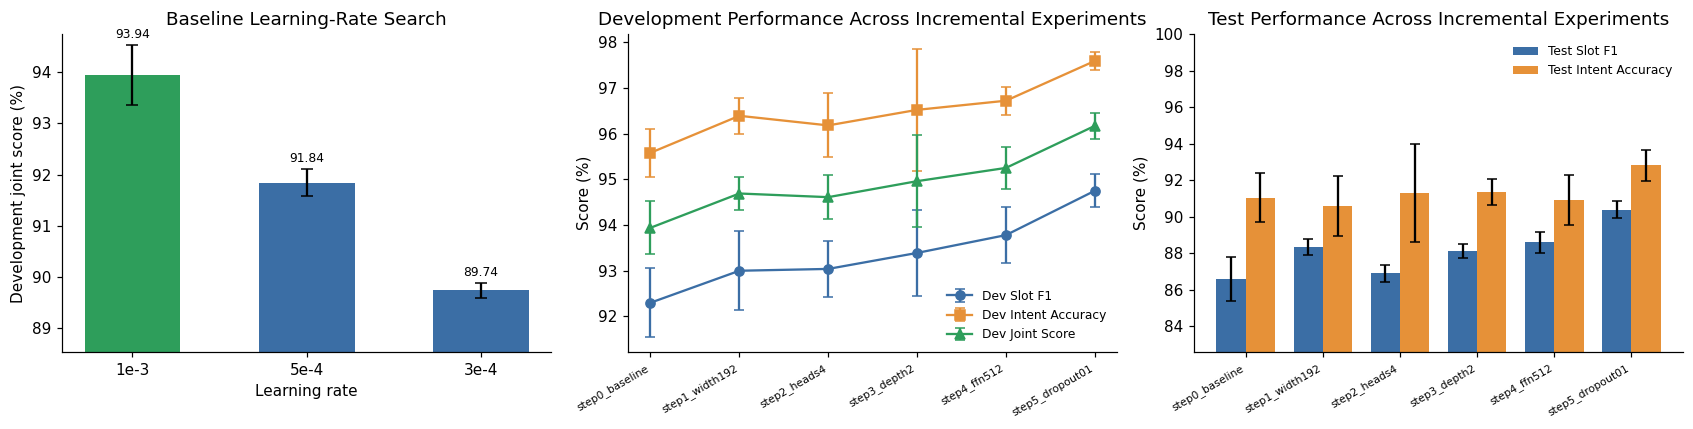

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.0))

# (a) learning-rate search, mean dev joint with std error bars
x = np.arange(len(lr_rows))
vals = [r['dev_joint'] for r in lr_rows]
errs = [r['dev_joint_std'] for r in lr_rows]
sel = int(np.argmax(vals))
colors = ['#3b6ea5'] * len(lr_rows); colors[sel] = '#2e9e5b'
b = axes[0].bar(x, vals, yerr=errs, capsize=4, color=colors, width=0.55)
axes[0].bar_label(b, fmt='%.2f', fontsize=8, padding=3)
axes[0].set_xticks(x, [r['name'].replace('base_lr', '') for r in lr_rows])
axes[0].set_xlabel('Learning rate'); axes[0].set_ylabel('Development joint score (%)')
axes[0].set_title('Baseline Learning-Rate Search')
axes[0].set_ylim(min(vals) - 1.2, max(vals) + 0.8)

# (b) development metrics across the incremental changes
xi = np.arange(len(inc_rows))
axes[1].errorbar(xi, [r['dev_f1'] for r in inc_rows],
                 yerr=[r['dev_f1_std'] for r in inc_rows], marker='o',
                 capsize=3, color='#3b6ea5', label='Dev Slot F1')
axes[1].errorbar(xi, [r['dev_acc'] for r in inc_rows],
                 yerr=[r['dev_acc_std'] for r in inc_rows], marker='s',
                 capsize=3, color='#e69138', label='Dev Intent Accuracy')
axes[1].errorbar(xi, [r['dev_joint'] for r in inc_rows],
                 yerr=[r['dev_joint_std'] for r in inc_rows], marker='^',
                 capsize=3, color='#2e9e5b', label='Dev Joint Score')
axes[1].set_xticks(xi, [r['name'] for r in inc_rows], rotation=30, ha='right', fontsize=7)
axes[1].set_ylabel('Score (%)'); axes[1].set_title('Development Performance Across Incremental Experiments')
axes[1].legend(frameon=False, fontsize=8)

# (c) held-out test metrics per configuration
w = 0.38
b1 = axes[2].bar(xi - w / 2, [r['test_f1'] for r in inc_rows], w,
                 yerr=[r['test_f1_std'] for r in inc_rows], capsize=3,
                 label='Test Slot F1', color='#3b6ea5')
b2 = axes[2].bar(xi + w / 2, [r['test_acc'] for r in inc_rows], w,
                 yerr=[r['test_acc_std'] for r in inc_rows], capsize=3,
                 label='Test Intent Accuracy', color='#e69138')
axes[2].set_xticks(xi, [r['name'] for r in inc_rows], rotation=30, ha='right', fontsize=7)
axes[2].set_ylabel('Score (%)'); axes[2].set_title('Test Performance Across Incremental Experiments')
axes[2].set_ylim(min(r['test_f1'] for r in inc_rows) - 4, 100)
axes[2].legend(frameon=False, fontsize=8)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Saving the selected configuration for Part 2.B

In [14]:
import json as _json

with open('part2A_best.json', 'w') as f:
    _json.dump({k: best[k] for k in
                ['name', 'lr', 'd_model', 'n_heads', 'num_layers', 'ff_dim', 'dropout',
                 'params', 'dev_joint', 'dev_joint_std', 'test_f1', 'test_f1_std',
                 'test_acc', 'test_acc_std', 'test_joint', 'test_joint_std']}, f, indent=1)

print('Part 2.A selected configuration written to part2A_best.json')
print(f"  {best['name']}: test Slot F1 {pm(best,'test_f1')} | "
      f"Intent {pm(best,'test_acc')} | Joint {pm(best,'test_joint')}")

Part 2.A selected configuration written to part2A_best.json
  step5_dropout01: test Slot F1 90.39 ± 0.48 | Intent 92.83 ± 0.85 | Joint 91.61 ± 0.36
